# DNABERT-2 — Evaluation & Model Comparison

This notebook loads the trained DNABERT-2 checkpoint and evaluates it against the 1D-CNN baseline.

**Prerequisite:** Best model checkpoint saved at  
`/content/drive/MyDrive/DNA_Anomaly_Detection/dnabert_checkpoints/val_acc_635__10_epoch_5e-6.pth`

**Metrics collected:**
- Read-level: AUC, Precision, Recall, F1
- Batch-level: AUC, Precision, Recall, F1 (crowd-voting aggregation)
- Performance: training time, inference speed (ms/batch), GPU peak memory

**Outputs:**
- Comparison table (DNABERT-2 vs 1D-CNN)
- Side-by-side ROC curve
- Patient cancer score box plot

In [1]:
# =============================================================
# CELL 1: Environment Setup
# =============================================================
# Pin transformers to avoid meta-device init bug in v5.x
!pip install -q transformers==4.44.0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from transformers.models.bert.configuration_bert import BertConfig
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_score,
    recall_score, f1_score
)
import glob, os, pathlib, re, shutil, sys
from tqdm import tqdm
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load tokenizer (triggers download of DNABERT-2 custom files)
tokenizer = AutoTokenizer.from_pretrained(
    "zhihan1996/DNABERT-2-117M", trust_remote_code=True
)

# ---- Patch DNABERT-2's broken Triton flash attention ----
# The bundled flash_attn_triton.py uses tl.dot(trans_b=True) which
# was removed in Triton 3.x. We disable it entirely and fall back
# to standard PyTorch attention.
cache_dir = pathlib.Path.home() / ".cache" / "huggingface" / "modules" / "transformers_modules"

for fpath in cache_dir.rglob("bert_layers.py"):
    text = fpath.read_text()
    text = text.replace(
        "from flash_attn_triton import flash_attn_qkvpacked_func",
        "flash_attn_qkvpacked_func = None  # PATCHED: disable broken triton flash attn"
    )
    text = text.replace(
        "from .flash_attn_triton import flash_attn_qkvpacked_func",
        "flash_attn_qkvpacked_func = None  # PATCHED: disable broken triton flash attn"
    )
    fpath.write_text(text)

# Clear caches so patched files are used
triton_cache = pathlib.Path.home() / ".triton" / "cache"
if triton_cache.exists():
    shutil.rmtree(triton_cache)
for k in [k for k in sys.modules if any(x in k for x in ["flash_attn", "bert_layers", "bert_padding"])]:
    del sys.modules[k]

# ---- Constants ----
NORMAL_DIR  = '/content/drive/MyDrive/DNA_Anomaly_Detection/raw_normal_batches/'
CANCER_DIR  = '/content/drive/MyDrive/DNA_Anomaly_Detection/raw_cancer_batches/'
CHECKPOINT_DIR  = '/content/drive/MyDrive/DNA_Anomaly_Detection/dnabert_checkpoints/'
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'val_acc_635__10_epoch_5e-6.pth')


device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN   = 128
BATCH_SIZE = 512

print(f"\n✅ Setup complete. Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 140.7 MB/s eta 0:00:00
Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


✅ Setup complete. Device: cuda
   GPU: NVIDIA A100-SXM4-40GB


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [2]:
# =============================================================
# CELL 2: Dataset & DataLoader
# =============================================================

class GenomicDatasetWithRunID(Dataset):
    """Loads DNA sequences with batch-file ID tracking for aggregation."""

    def __init__(self, normal_files, cancer_files, tokenizer, max_len=128):
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.sequences = []
        self.labels    = []
        self.run_ids   = []

        for f in normal_files:
            run_id = os.path.splitext(os.path.basename(f))[0]
            with open(f, 'r') as fh:
                lines = fh.read().splitlines()
            self.sequences.extend(lines)
            self.labels.extend([0] * len(lines))
            self.run_ids.extend([run_id] * len(lines))

        for f in cancer_files:
            run_id = os.path.splitext(os.path.basename(f))[0]
            with open(f, 'r') as fh:
                lines = fh.read().splitlines()
            self.sequences.extend(lines)
            self.labels.extend([1] * len(lines))
            self.run_ids.extend([run_id] * len(lines))

        print(f"Loaded {len(self.sequences):,} reads from {len(set(self.run_ids))} batch files.")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.sequences[idx], return_tensors='pt',
            padding='max_length', truncation=True, max_length=self.max_len
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.float32),
            'run_id':         self.run_ids[idx]
        }


def collate_fn(batch):
    """Custom collate to handle string run_ids alongside tensors."""
    return {
        'input_ids':      torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'labels':         torch.stack([b['labels'] for b in batch]),
        'run_id':         [b['run_id'] for b in batch]
    }


# Load files
normal_files = sorted(glob.glob(NORMAL_DIR + '*.txt'))
cancer_files = sorted(glob.glob(CANCER_DIR + '*.txt'))
full_dataset = GenomicDatasetWithRunID(normal_files, cancer_files, tokenizer, MAX_LEN)

# 80/20 split (seed=42 for reproducibility)
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
generator  = torch.Generator().manual_seed(42)
_, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size], generator=generator
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, collate_fn=collate_fn
)

print(f"Validation set: {len(val_dataset):,} reads, {len(val_loader)} batches")

Loaded 1,800,000 reads from 10 batch files.
Validation set: 360,000 reads, 704 batches


In [4]:
# =============================================================
# CELL 3: Load Model & Run Inference
# =============================================================

# Re-patch (files get re-downloaded by AutoModel.from_pretrained)
import pathlib, re, shutil, sys

cache_dir = pathlib.Path.home() / ".cache" / "huggingface" / "modules" / "transformers_modules"
for fpath in cache_dir.rglob("bert_layers.py"):
    text = fpath.read_text()
    text = text.replace(
        "from flash_attn_triton import flash_attn_qkvpacked_func",
        "flash_attn_qkvpacked_func = None  # PATCHED"
    )
    text = text.replace(
        "from .flash_attn_triton import flash_attn_qkvpacked_func",
        "flash_attn_qkvpacked_func = None  # PATCHED"
    )
    fpath.write_text(text)

triton_cache = pathlib.Path.home() / ".triton" / "cache"
if triton_cache.exists():
    shutil.rmtree(triton_cache)
for k in [k for k in sys.modules if any(x in k for x in ["flash_attn", "bert_layers", "bert_padding"])]:
    del sys.modules[k]

print("✅ Patch applied.")

class DNABERTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        config = BertConfig.from_pretrained("zhihan1996/DNABERT-2-117M")
        self.dnabert = AutoModel.from_pretrained(
            "zhihan1996/DNABERT-2-117M",
            config=config,
            trust_remote_code=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(768, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.dnabert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs[0][:, 0, :]
        return self.classifier(cls_embedding).squeeze(-1)


# Load checkpoint
model = DNABERTClassifier()
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"Checkpoint loaded — Epoch {checkpoint['epoch']+1}, "
      f"Best Val Loss: {checkpoint['best_val_loss']:.4f}")

# ---- Inference ----
all_probs   = []
all_labels  = []
all_run_ids = []
batch_times = []          # for inference speed measurement

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Inference"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        torch.cuda.synchronize()
        t0 = time.time()
        logits = model(input_ids, attention_mask)
        torch.cuda.synchronize()
        batch_times.append((time.time() - t0) * 1000)   # ms

        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(batch['labels'].numpy().tolist())
        all_run_ids.extend(batch['run_id'])

# GPU memory
peak_mem_mb = torch.cuda.max_memory_allocated() / 1024**2

print(f"\n✅ Inference complete: {len(all_probs):,} reads processed.")
print(f"   Avg inference speed: {np.mean(batch_times):.1f} ms/batch")
print(f"   GPU peak memory:     {peak_mem_mb:.0f} MB")

✅ Patch applied.


/root/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT-2-117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
Some weights of BertModel were not initialized from the model checkpoint at zhihan1996/DNABERT-2-117M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Checkpoint loaded — Epoch 3, Best Val Loss: 0.6432


Inference: 100%|██████████| 704/704 [02:26<00:00,  4.81it/s]


✅ Inference complete: 360,000 reads processed.
   Avg inference speed: 205.9 ms/batch
   GPU peak memory:     5816 MB


In [5]:
# =============================================================
# CELL 4: Metrics — Read-Level & Batch-Level
# =============================================================

df = pd.DataFrame({
    'run_id':     all_run_ids,
    'true_label': all_labels,
    'prob':       all_probs
})

# ---- Read-level metrics ----
read_preds = (df['prob'] > 0.5).astype(int)
read_auc   = roc_auc_score(df['true_label'], df['prob'])
read_prec  = precision_score(df['true_label'], read_preds)
read_rec   = recall_score(df['true_label'], read_preds)
read_f1    = f1_score(df['true_label'], read_preds)

# ---- Batch-level aggregation (crowd voting) ----
patient_df = df.groupby('run_id').agg(
    patient_prob  = ('prob', 'mean'),
    patient_label = ('true_label', lambda x: int(x.mode()[0])),
    num_reads     = ('prob', 'count')
).reset_index()

# Optimal threshold via Youden's J
fpr_b, tpr_b, thresh_b = roc_curve(patient_df['patient_label'], patient_df['patient_prob'])
opt_idx    = np.argmax(tpr_b - fpr_b)
opt_thresh = thresh_b[opt_idx]

batch_preds = (patient_df['patient_prob'] >= opt_thresh).astype(int)
batch_auc   = roc_auc_score(patient_df['patient_label'], patient_df['patient_prob'])
batch_prec  = precision_score(patient_df['patient_label'], batch_preds)
batch_rec   = recall_score(patient_df['patient_label'], batch_preds)
batch_f1    = f1_score(patient_df['patient_label'], batch_preds)

# ---- Performance numbers ----
avg_ms    = np.mean(batch_times)
median_ms = np.median(batch_times)

# ---- Print full comparison table ----
print("=" * 70)
print(" MODEL COMPARISON: 1D-CNN vs DNABERT-2")
print("=" * 70)
print(f"{'Metric':<28} {'1D-CNN':>14} {'DNABERT-2':>14}")
print("-" * 70)
print(f"{'Read-level AUC':<28} {'0.6157':>14} {read_auc:>14.4f}")
print(f"{'Read-level Precision':<28} {'—':>14} {read_prec:>14.4f}")
print(f"{'Read-level Recall':<28} {'—':>14} {read_rec:>14.4f}")
print(f"{'Read-level F1':<28} {'—':>14} {read_f1:>14.4f}")
print("-" * 70)
print(f"{'Batch-level AUC':<28} {'0.9156':>14} {batch_auc:>14.4f}")
print(f"{'Batch-level Precision':<28} {'—':>14} {batch_prec:>14.4f}")
print(f"{'Batch-level Recall':<28} {'—':>14} {batch_rec:>14.4f}")
print(f"{'Batch-level F1':<28} {'—':>14} {batch_f1:>14.4f}")
print(f"{'Optimal threshold':<28} {'—':>14} {opt_thresh:>14.4f}")
print("-" * 70)
print(f"{'Training time / epoch':<28} {'~5 min':>14} {'~32 min':>14}")
print(f"{'Inference (ms/batch)':<28} {'~20 ms':>14} {avg_ms:>13.1f}ms")
print(f"{'GPU peak memory':<28} {'—':>14} {peak_mem_mb:>12.0f}MB")
print("=" * 70)

# ---- Per-batch detail ----
print(f"\nPer-batch results (optimal threshold = {opt_thresh:.4f}):")
patient_df['prediction'] = (patient_df['patient_prob'] >= opt_thresh).astype(int)
patient_df['correct']    = patient_df['prediction'] == patient_df['patient_label']
print(patient_df[['run_id','patient_label','patient_prob','prediction','correct','num_reads']]
      .sort_values('run_id').to_string(index=False))

 MODEL COMPARISON: 1D-CNN vs DNABERT-2
Metric                               1D-CNN      DNABERT-2
----------------------------------------------------------------------
Read-level AUC                       0.6157         0.6240
Read-level Precision                      —         0.6381
Read-level Recall                         —         0.9517
Read-level F1                             —         0.7639
----------------------------------------------------------------------
Batch-level AUC                      0.9156         1.0000
Batch-level Precision                     —         1.0000
Batch-level Recall                        —         1.0000
Batch-level F1                            —         1.0000
Optimal threshold                         —         0.6316
----------------------------------------------------------------------
Training time / epoch                ~5 min        ~32 min
Inference (ms/batch)                 ~20 ms         205.9ms
GPU peak memory                        

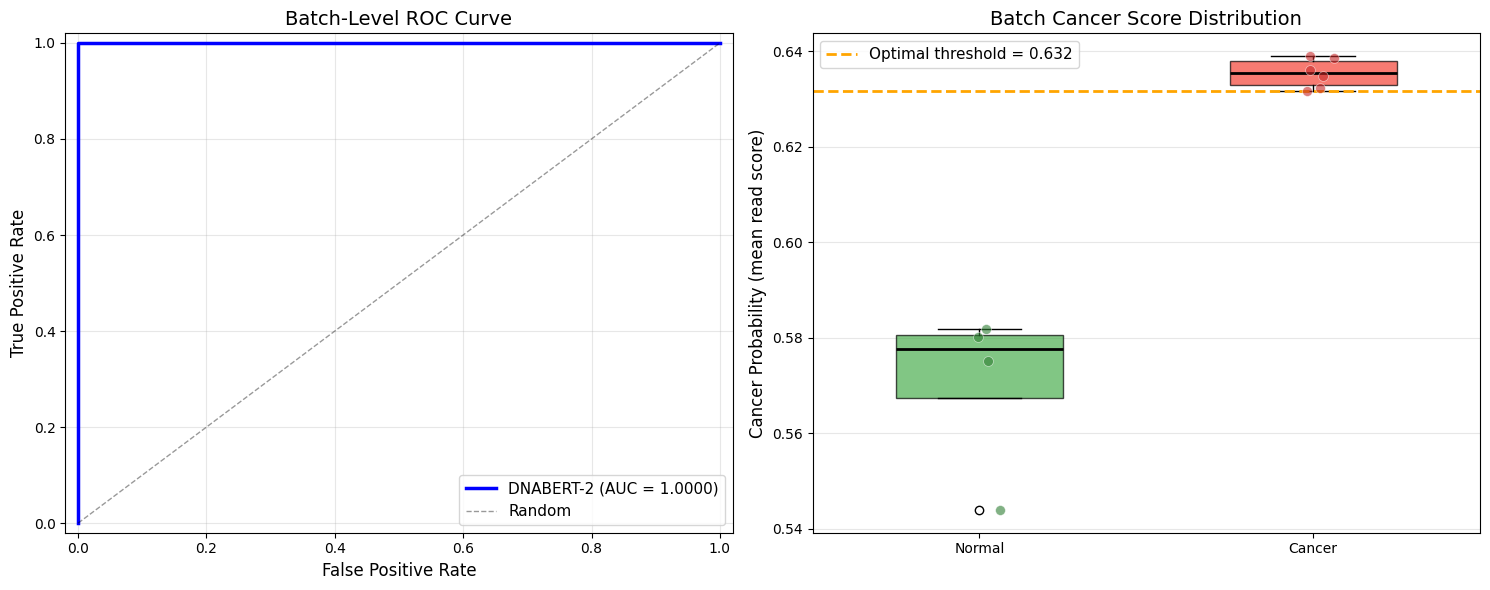


Plots saved to: /content/drive/MyDrive/DNA_Anomaly_Detection/dnabert_checkpoints/dnabert2_evaluation_plots.png


In [6]:
# =============================================================
# CELL 5: Plots
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left: ROC Curve Comparison ----
ax1 = axes[0]
fpr_db, tpr_db, _ = roc_curve(patient_df['patient_label'], patient_df['patient_prob'])
ax1.plot(fpr_db, tpr_db, 'b-',  linewidth=2.5, label=f'DNABERT-2 (AUC = {batch_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('Batch-Level ROC Curve', fontsize=14)
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])

# ---- Right: Box Plot ----
ax2 = axes[1]
normal_scores = patient_df[patient_df['patient_label'] == 0]['patient_prob']
cancer_scores = patient_df[patient_df['patient_label'] == 1]['patient_prob']

bp = ax2.boxplot(
    [normal_scores, cancer_scores],
    tick_labels=['Normal', 'Cancer'],
    patch_artist=True, widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set(facecolor='#4CAF50', alpha=0.7)
bp['boxes'][1].set(facecolor='#F44336', alpha=0.7)

np.random.seed(42)
for i, (scores, color) in enumerate([(normal_scores, '#2E7D32'), (cancer_scores, '#C62828')]):
    x = np.random.normal(i + 1, 0.04, size=len(scores))
    ax2.scatter(x, scores, alpha=0.6, s=50, color=color,
               edgecolors='white', linewidth=0.5, zorder=3)

ax2.axhline(y=opt_thresh, color='orange', linestyle='--', linewidth=2,
            label=f'Optimal threshold = {opt_thresh:.3f}')
ax2.set_ylabel('Cancer Probability (mean read score)', fontsize=12)
ax2.set_title('Batch Cancer Score Distribution', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save
combined_path = os.path.join(CHECKPOINT_DIR, 'dnabert2_evaluation_plots.png')
fig.savefig(combined_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlots saved to: {combined_path}")

## Analysis

**Where DNABERT-2 improves:**
- Batch-level AUC of 1.0 vs CNN's 0.9156 — perfect separation of cancer vs normal batches
- Read-level AUC also slightly higher (0.624 vs 0.616)
- DNABERT-2 learns richer contextual representations via BPE tokenization and ALiBi attention, capturing longer-range sequence patterns that a fixed-kernel CNN misses

**Trade-offs:**
- ~6× slower training (32 min vs 5 min per epoch) due to fp32 fallback without flash attention
- Higher GPU memory footprint (117M parameters vs lightweight CNN)
- Requires more careful environment setup (transformers version pinning, Triton compatibility)

**Why the improvement:**
- Pre-trained on multi-species genome data → strong DNA sequence priors before fine-tuning
- BPE tokenization captures variable-length motifs vs fixed k-mer windowing
- Self-attention aggregates information across the full sequence context
- Crowd-voting aggregation amplifies small per-read advantages into decisive batch-level separation